Panaroo Structural Variants in a Clonal Group (struct `.Rtab`)

`struct_presence_absence.Rtab` is tab-separated with header `Gene` then sample IDs: **rows = structural variant IDs**, **columns = 0/1 presence** (Panaroo). AnnData uses **obs = samples**, **var = variants**, so we **transpose** after read.

Pandas: `pd.read_csv(path, sep="\t", index_col=0)` — much faster than the CSV because cells are numeric, not long strings.

For the **full gene** binary matrix (not only structural variants), point `rtab_path` at `gene_presence_absence.Rtab` (same format).

**Note:** Structural variants are a **subset** of pangenome signal vs all genes — choose the file that matches your question.

In [11]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import anndata as ad

from predict_kleb_by_bacformer.tl.panaroo_pangenome_features import (
    feature_frequency_distribution,
    features_per_sample,
    filter_by_prevalence,
    per_sample_counts_core_shell_cloud,
)

In [12]:
strain = "CG14"
CORE_FREQ = 0.95
CLOUD_FREQ = 0.05
FILTER_CUTOFF = 10

In [13]:
project_k_dir = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/"
panaroo_dir = project_k_dir + "processed/panaroo_run/"
strain_dir = panaroo_dir + strain + "_all" + "/"

rtab_path = strain_dir + "struct_presence_absence.Rtab"
# rtab_path = strain_dir + "gene_presence_absence.Rtab"  # all genes, binary

struct_df = pd.read_csv(rtab_path, sep="\t", index_col=0)
struct_df.columns = struct_df.columns.astype(str)

n_variants, n_samples = struct_df.shape
print(f"Loaded {rtab_path}")
print(f"  variants (rows): {n_variants},  samples (cols): {n_samples}")

Loaded /home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/panaroo_run/CG14_all/struct_presence_absence.Rtab
  variants (rows): 19100,  samples (cols): 2232


Present structural variants (panaroo) per sample (column sums)
  n_samples: 2232
  min:  1480 structural variants per sample
  max:  2192 structural variants per sample
  mean: 1837.71 structural variants per sample
  sd:   88.86 structural variants per sample


FeaturePerSampleResult(fig=<Figure size 800x400 with 1 Axes>, counts_per_sample=SAMD00055755                            1709
SAMD00055756                            1827
SAMD00055757                            1689
SAMD00055758                            1824
SAMD00055759                            1719
                                        ... 
GCF_011742055.2_ASM1174205v2_genomic    2029
GCF_026427375.1_ASM2642737v1_genomic    1956
GCF_034479915.1_ASM3447991v1_genomic    1885
GCF_019286855.1_ASM1928685v1_genomic    2042
GCF_019317205.1_ASM1931720v1_genomic    2117
Length: 2232, dtype: int64, n_samples=2232)

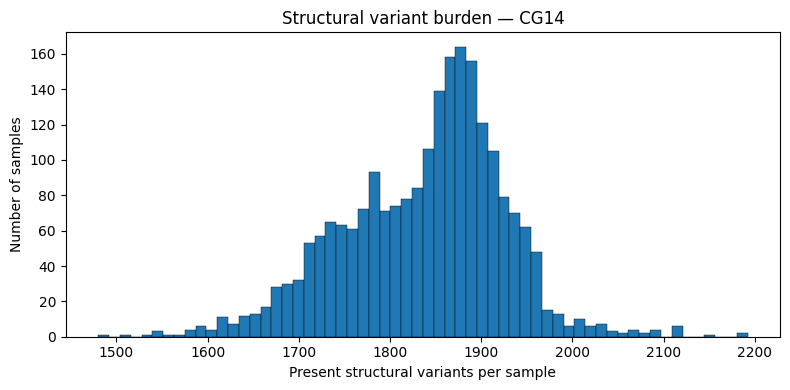

In [ ]:
res = features_per_sample(struct_df, strain, feature_label="structural variant")

Total structural variants: 19100
  Core  (>95% samples):     548  (2.9%)
  Shell (5–95%):           3182  (16.7%)
  Cloud (<5%):            15370  (80.5%)
  Panaroo cutoff (<0.01%):      12521  (65.6%)
  Ubiquitous (100%):                   0  (0.0%)


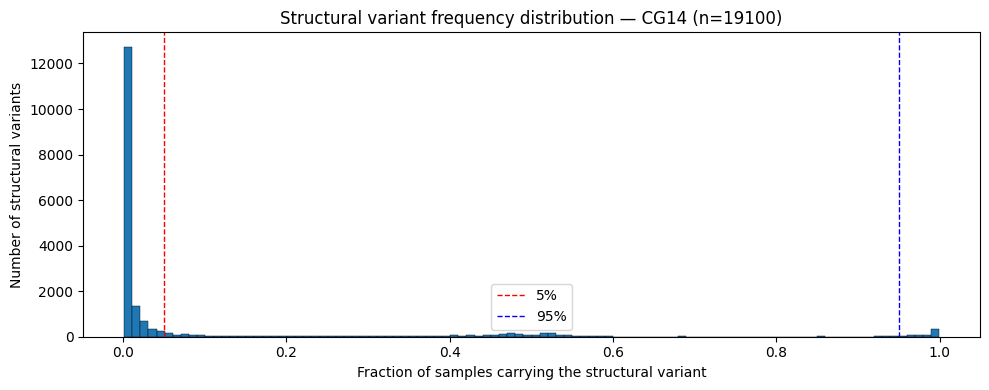

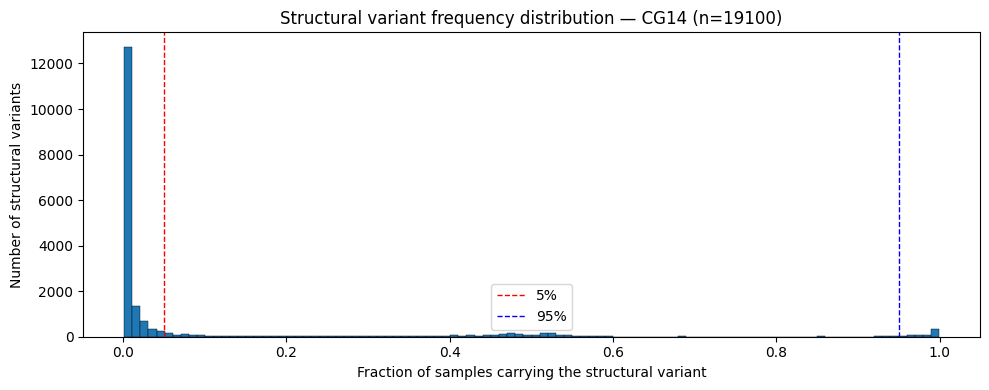

In [ ]:
res = feature_frequency_distribution(
    struct_df, strain, feature_label="structural variant", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

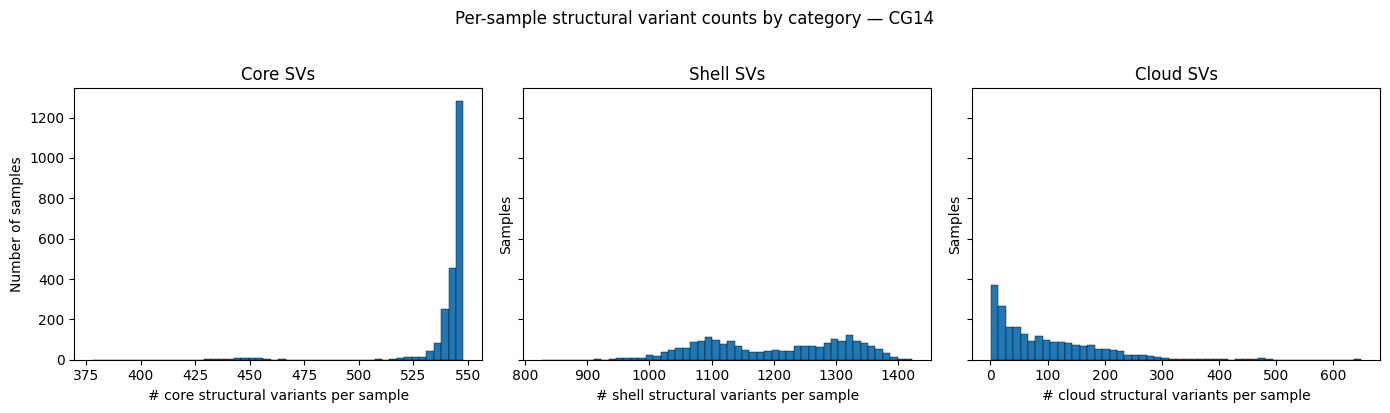

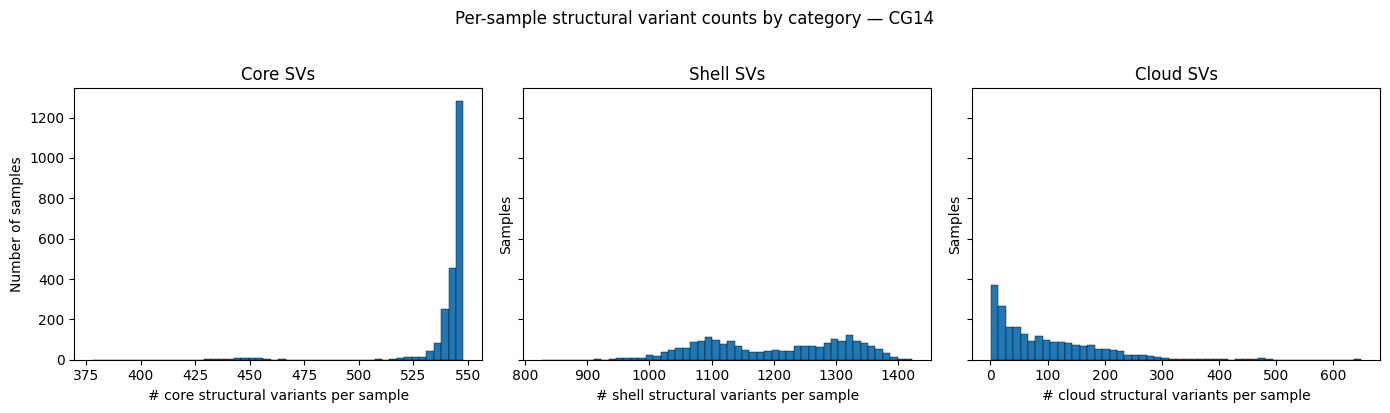

In [ ]:
res = per_sample_counts_core_shell_cloud(
    struct_df, strain, feature_label="structural variant", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

In [ ]:
res = struct_df_filt = filter_by_prevalence(
    struct_df, min_prevalence=FILTER_CUTOFF, feature_label="structural variant"
)

filter_by_prevalence (structural variant): 19100 -> 9120 features (min_prevalence=10 samples)


Present structural variants (panaroo) per sample (column sums)
  n_samples: 2232
  min:  1460 structural variants per sample
  max:  2081 structural variants per sample
  mean: 1820.59 structural variants per sample
  sd:   89.20 structural variants per sample


FeaturePerSampleResult(fig=<Figure size 800x400 with 1 Axes>, counts_per_sample=SAMD00055755                            1683
SAMD00055756                            1782
SAMD00055757                            1665
SAMD00055758                            1777
SAMD00055759                            1691
                                        ... 
GCF_011742055.2_ASM1174205v2_genomic    1962
GCF_026427375.1_ASM2642737v1_genomic    1892
GCF_034479915.1_ASM3447991v1_genomic    1797
GCF_019286855.1_ASM1928685v1_genomic    1978
GCF_019317205.1_ASM1931720v1_genomic    2058
Length: 2232, dtype: int64, n_samples=2232)

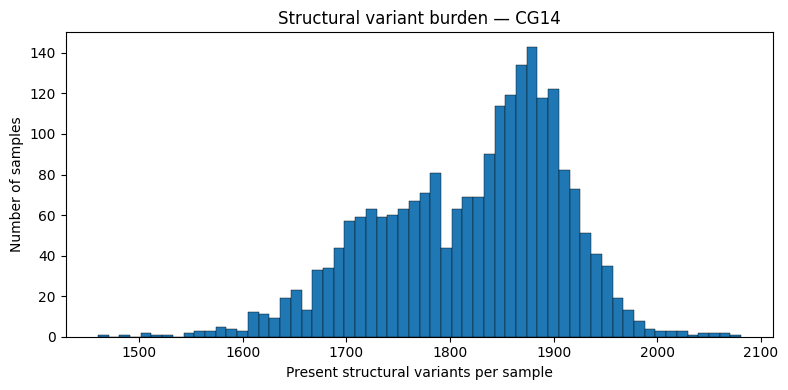

In [ ]:
fps = features_per_sample(struct_df_filt, strain, feature_label="structural variant")

Total structural variants: 9120
  Core  (>95% samples):     548  (6.0%)
  Shell (5–95%):           3182  (34.9%)
  Cloud (<5%):             5390  (59.1%)
  Panaroo cutoff (<1%):       2541  (27.9%)
  Ubiquitous (100%):                   0  (0.0%)


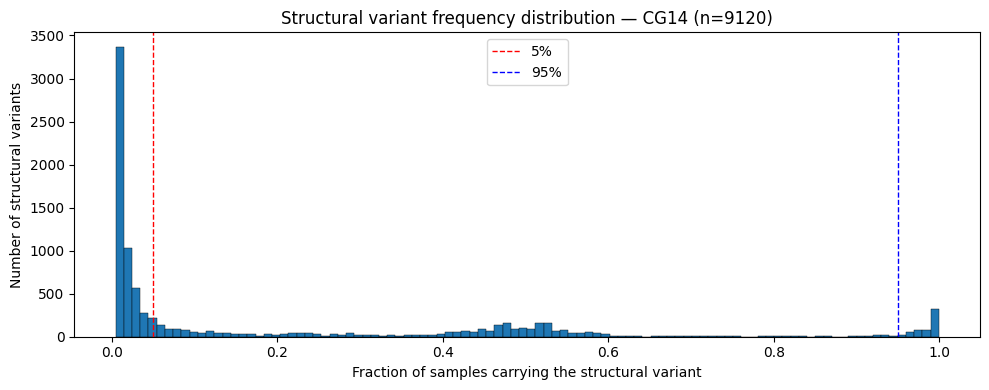

In [22]:
ffd = feature_frequency_distribution(
    struct_df_filt, strain, feature_label="structural variant", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

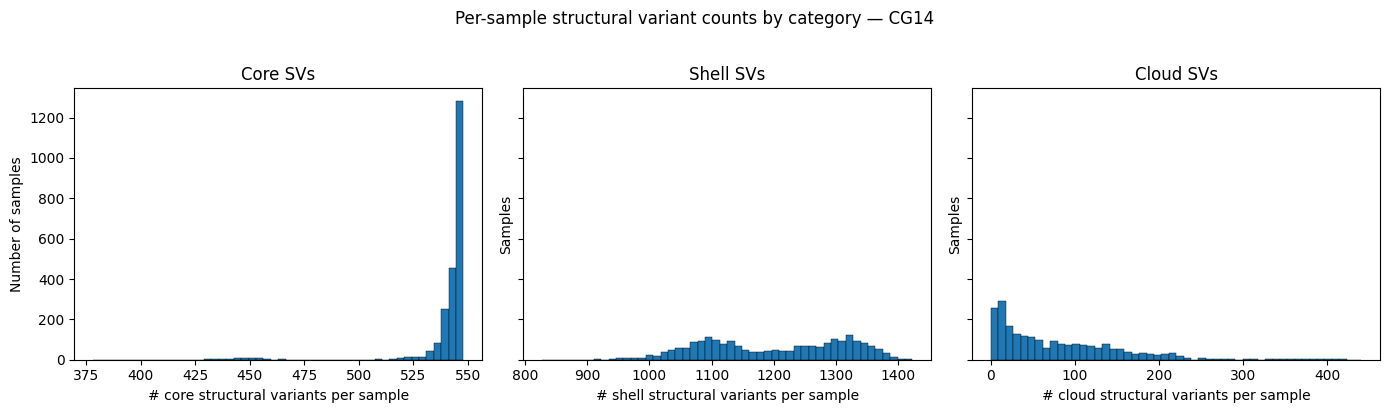

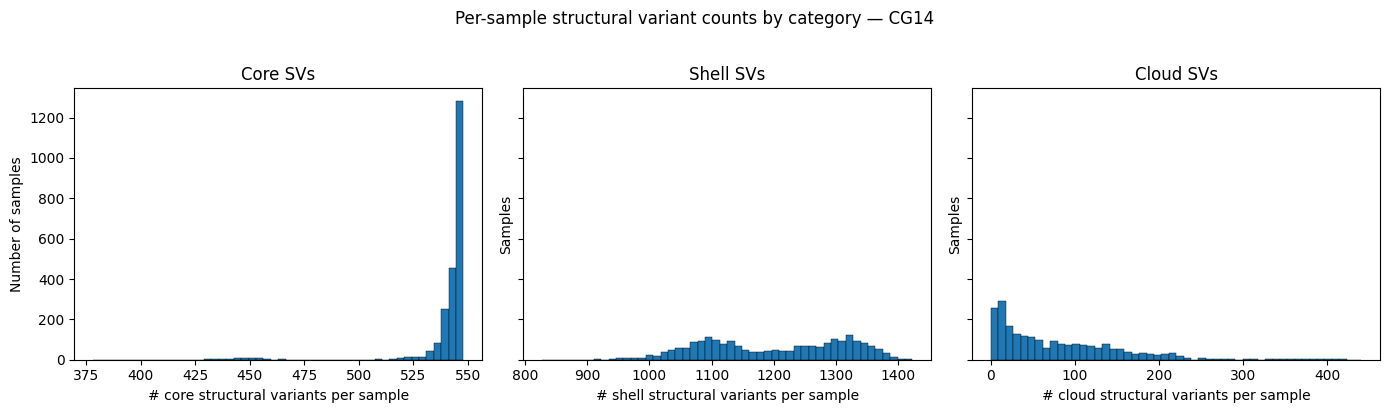

In [ ]:
res = per_sample_counts_core_shell_cloud(
    struct_df_filt, strain, feature_label="structural variant", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)